In [1]:
import numpy as np
import pandas as pd

%matplotlib inline

import matplotlib.pyplot as plt

import seaborn as sns

import os

from PIL import Image

import warnings
warnings.filterwarnings("ignore")

import torch

import torch.nn as nn
import torch.optim as optim

import torchvision

from torchvision.transforms import transforms

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"using {device}")

using cuda


In [3]:
labels = []
paths = []

for label in os.listdir("../datasets/AlzheimerBrainMRI"):
    for image_path in os.listdir(f"../datasets/AlzheimerBrainMRI/{label}"):
        labels.append(label)
        paths.append(f"../datasets/AlzheimerBrainMRI/{label}/{image_path}")
        
data_df = pd.DataFrame(zip(paths, labels), columns= ["image_path", "label"])
data_df.head()  

,image_path,label
0,../datasets/AlzheimerBrainMRI/Demented/mild.jpg,Demented
1,../datasets/AlzheimerBrainMRI/Demented/mild_10...,Demented
2,../datasets/AlzheimerBrainMRI/Demented/mild_10...,Demented
3,../datasets/AlzheimerBrainMRI/Demented/mild_10...,Demented
4,../datasets/AlzheimerBrainMRI/Demented/mild_10...,Demented


In [5]:
from utils.Preprocessing import create_dataloader

train_loader, val_loader = create_dataloader(dataframe= data_df, includeTest= False)

original dataframe shape: (6336, 2)
training dataframe shape: (5069, 2)
validation dataframe shape: (1267, 2)


In [6]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.to(device)

#freeze
for param in model.parameters():
    param.requires_grad = False

#новый классификатор
model.fc = nn.Linear(model.fc.in_features, data_df["label"].nunique())
model.to(device) 

#оптимизатор только для fc
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

In [7]:
from utils.LearningFuncs import train_model

history = train_model(model= model, 
        train_loader= train_loader, 
        val_loader= val_loader, 
        criterion= criterion, 
        optimizer= optimizer, 
        device= device, 
        num_epochs= 10)

Epoch 1, Train loss: 0.6782, Validation loss: 0.6249,          Train accuracy: 0.6090, Validation accuracy: 0.6582
Epoch 2, Train loss: 0.6196, Validation loss: 0.6589,          Train accuracy: 0.6640, Validation accuracy: 0.6717
Epoch 3, Train loss: 0.6054, Validation loss: 0.6194,          Train accuracy: 0.6753, Validation accuracy: 0.6827
Epoch 4, Train loss: 0.6001, Validation loss: 0.6266,          Train accuracy: 0.6814, Validation accuracy: 0.6788
Epoch 5, Train loss: 0.6071, Validation loss: 0.6008,          Train accuracy: 0.6784, Validation accuracy: 0.6851
Epoch 6, Train loss: 0.6049, Validation loss: 0.6111,          Train accuracy: 0.6747, Validation accuracy: 0.6843
Epoch 7, Train loss: 0.5885, Validation loss: 0.5952,          Train accuracy: 0.6952, Validation accuracy: 0.7080
Epoch 8, Train loss: 0.6007, Validation loss: 0.6035,          Train accuracy: 0.6836, Validation accuracy: 0.6938
Epoch 9, Train loss: 0.5830, Validation loss: 0.6285,          Train accuracy: 0

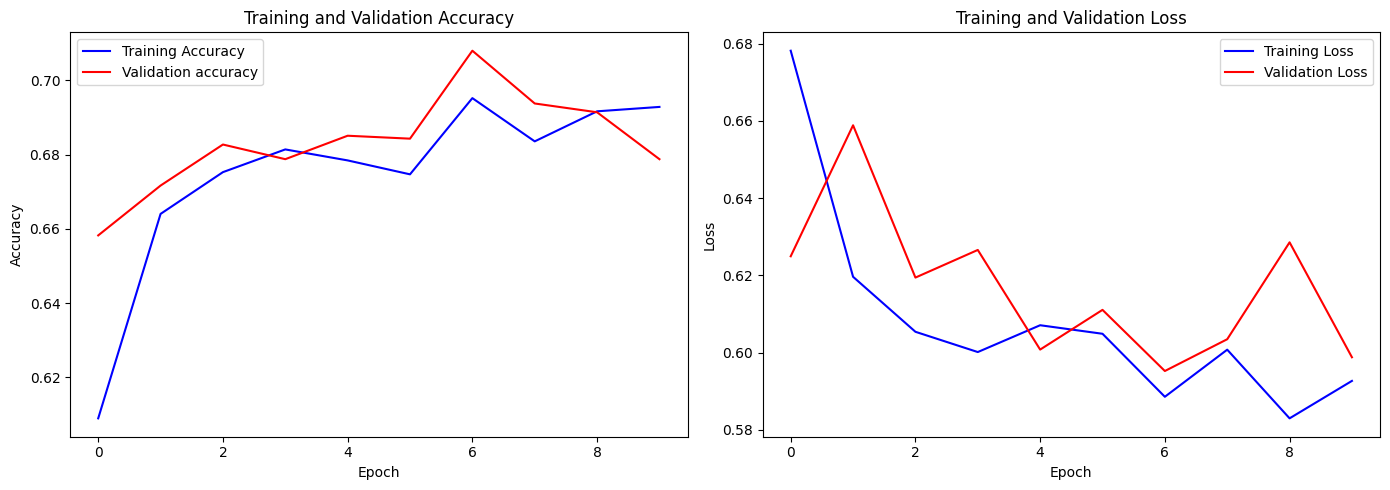

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

axs[0].plot(history["Epoch"], history["Train accuracy"], label= "Training Accuracy", color= "blue")
axs[0].plot(history["Epoch"], history["Validation accuracy"], label= "Validation accuracy", color= "red")
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Accuracy')
axs[0].set_title('Training and Validation Accuracy')
axs[0].legend()

axs[1].plot(history["Epoch"], history["Train Loss"], label= "Training Loss", color= "blue")
axs[1].plot(history["Epoch"], history["Validation Loss"], label= "Validation Loss", color= "red")
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].set_title('Training and Validation Loss')
axs[1].legend()

plt.tight_layout()
plt.show()

In [9]:
#unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

# оптимизатор только для обучаемых параметров
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)


history = pd.concat([history, train_model(model= model, 
                                    train_loader= train_loader, 
                                    val_loader= val_loader, 
                                    criterion= criterion, 
                                    optimizer= optimizer, 
                                    device= device, 
                                    num_epochs= 10)])

history["Epoch"] = range(1, history.shape[0] +1)

Epoch 1, Train loss: 0.5838, Validation loss: 0.5580,          Train accuracy: 0.6954, Validation accuracy: 0.7277
Epoch 2, Train loss: 0.5122, Validation loss: 0.5385,          Train accuracy: 0.7453, Validation accuracy: 0.7482
Epoch 3, Train loss: 0.4799, Validation loss: 0.5081,          Train accuracy: 0.7637, Validation accuracy: 0.7545
Epoch 4, Train loss: 0.4690, Validation loss: 0.4578,          Train accuracy: 0.7761, Validation accuracy: 0.7853
Epoch 5, Train loss: 0.4347, Validation loss: 0.4978,          Train accuracy: 0.7935, Validation accuracy: 0.7845
Epoch 6, Train loss: 0.4157, Validation loss: 0.4690,          Train accuracy: 0.8057, Validation accuracy: 0.7908
Epoch 7, Train loss: 0.3986, Validation loss: 0.4424,          Train accuracy: 0.8193, Validation accuracy: 0.8051
Epoch 8, Train loss: 0.3829, Validation loss: 0.4069,          Train accuracy: 0.8325, Validation accuracy: 0.8185
Epoch 9, Train loss: 0.3584, Validation loss: 0.4103,          Train accuracy: 0

In [10]:
torch.save(model.state_dict(), "../models/Alzheimer.pt")

In [11]:
torch.cuda.empty_cache()

!nvidia-smi

Sun Aug  2 19:28:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 610.74                 KMD Version: 610.74        CUDA UMD Version: 13.3     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3060 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   53C    P8             10W /  105W |     350MiB /   6144MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----